In [23]:
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
import math

In [24]:
SAMPLES = 1000
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED) #Garantizar la generación de los mismos números aleatorios.


<function matplotlib.pyplot.show(close=None, block=None)>

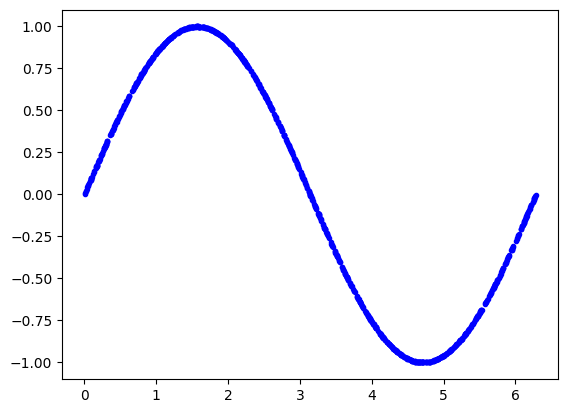

In [25]:
x_values = np.random.uniform(low=0, high=2*math.pi, size=SAMPLES) #Generación de número aleatorios uniformes
np.random.shuffle(x_values) # Mezcla los números generados anteriormente en un orden diferente
y_values = np.sin(x_values) # Obtiene el seno de cada valor de x
plt.plot(x_values, y_values, 'b.')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

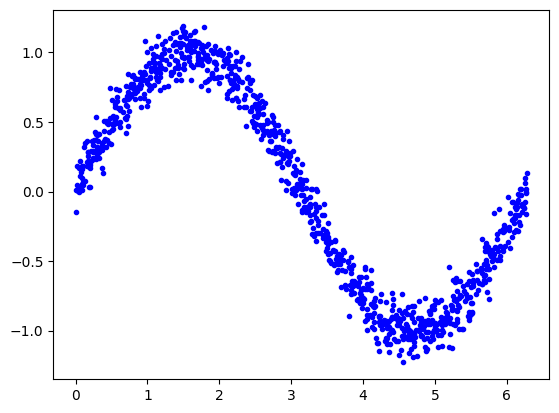

In [26]:
y_values += 0.1 * np.random.randn(*y_values.shape) #Anañe ruidos a los valores generados anteriormente
plt.plot(x_values, y_values, 'b.')
plt.show


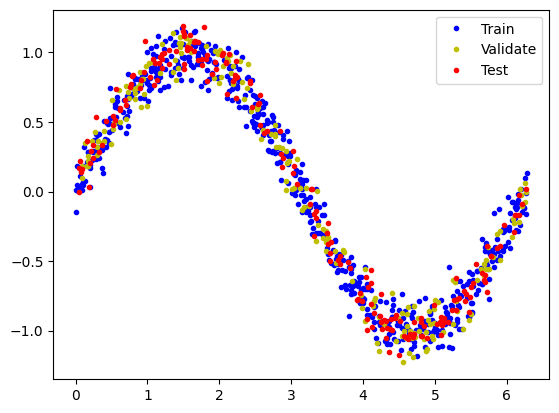

In [27]:
TRAIN_SPLIT = int(0.6 * SAMPLES)  #60% para entrenar el modelo
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT) #

x_train, x_validate, x_test = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT]) #Divide los datos para X
y_train, y_validate, y_test = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT]) # Divide los datos para y

assert (x_train.size + x_validate.size + x_test.size) == SAMPLES #Verifica si la división se realizó correctamente

#Graficas los datos
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_validate, y_validate, 'y.', label="Validate")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.legend()
plt.show()

In [28]:
from tensorflow.keras import layers
model_1 = tf.keras.Sequential()
model_1.add(layers.Dense(16, activation='relu', input_shape=(1,))) #1 capa de entrada (1 entrada)
model_1.add(layers.Dense(1)) # 1 capa de salida
model_1.compile(optimizer='rmsprop', loss='mse', metrics=['mae']) #Compilación del modelo.
model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_1 = model_1.fit(x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_validate, y_validate))


Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3937 - mae: 0.5430 - val_loss: 0.3872 - val_mae: 0.5392
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3442 - mae: 0.5091 - val_loss: 0.3409 - val_mae: 0.5026
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3042 - mae: 0.4790 - val_loss: 0.3018 - val_mae: 0.4714
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2709 - mae: 0.4529 - val_loss: 0.2696 - val_mae: 0.4452
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2439 - mae: 0.4308 - val_loss: 0.2438 - val_mae: 0.4240
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2228 - mae: 0.4125 - val_loss: 0.2239 - val_mae: 0.4070
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2068 - mae: 0.3976 - val_loss: 0.2091 - val_mae: 0.3942
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1952 - mae: 0.3862 - val_loss: 0.1982 - val_mae: 0.3840
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

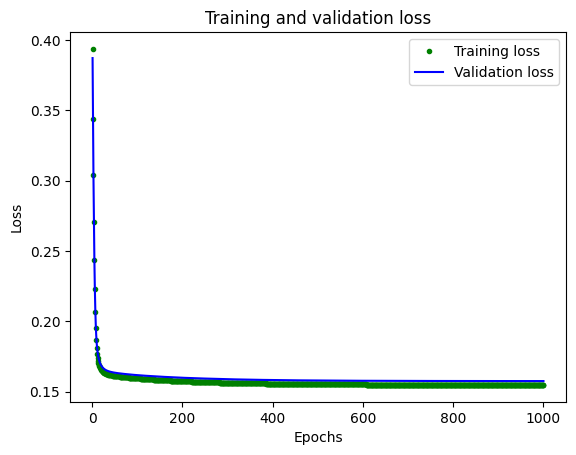

In [30]:
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

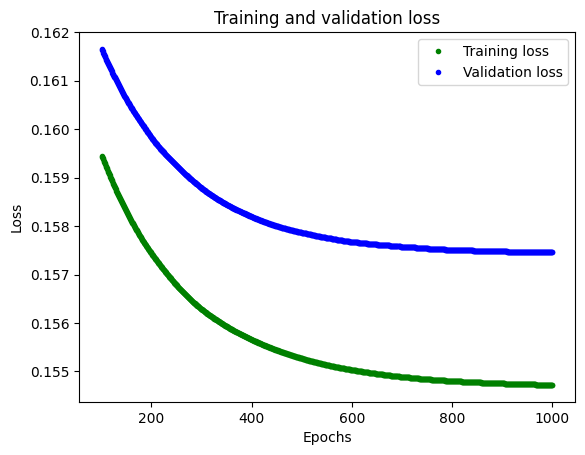

In [31]:
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

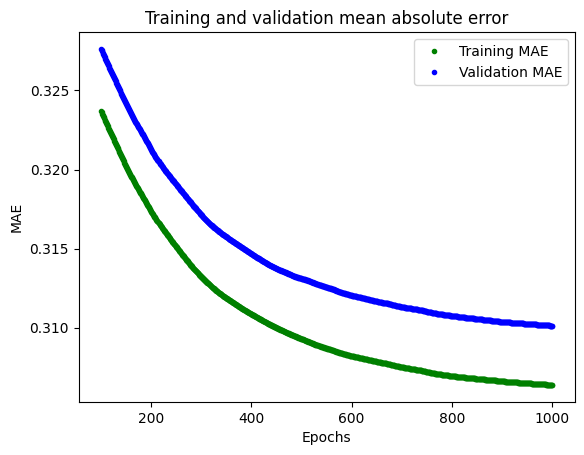

In [32]:
mae = history_1.history['mae']
val_mae = history_1.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


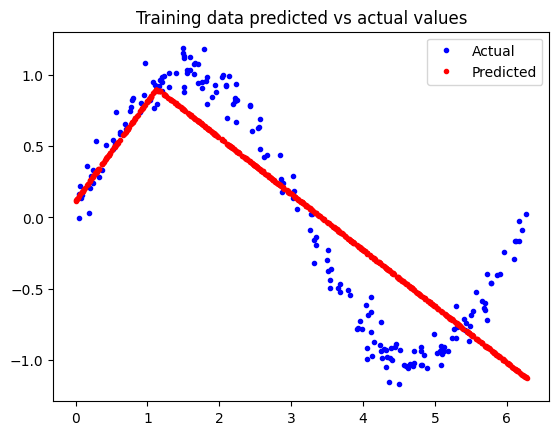

In [33]:

predictions = model_1.predict(x_train)

plt.clf()
plt.title('Training data predicted vs actual values')
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_train, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()

In [34]:
#Creación de un segundo modelo

model_2 = tf.keras.Sequential()
model_2.add(layers.Dense(16, activation='relu', input_shape=(1,))) #Una capa de entrada
model_2.add(layers.Dense(16, activation='relu')) # Capa intermedia
model_2.add(layers.Dense(1)) #Capa de salida
model_2.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_2 = model_2.fit(x_train, y_train, epochs=600, batch_size=16, validation_data=(x_validate, y_validate))


Epoch 1/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7248 - mae: 0.7117 - val_loss: 0.4548 - val_mae: 0.5889
Epoch 2/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3948 - mae: 0.5438 - val_loss: 0.3761 - val_mae: 0.5297
Epoch 3/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3308 - mae: 0.4976 - val_loss: 0.3151 - val_mae: 0.4812
Epoch 4/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2802 - mae: 0.4580 - val_loss: 0.2678 - val_mae: 0.4426
Epoch 5/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2418 - mae: 0.4252 - val_loss: 0.2326 - val_mae: 0.4120
Epoch 6/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2142 - mae: 0.3996 - val_loss: 0.2080 - val_mae: 0.3885
Epoch 7/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1953 - mae: 0.3796 - val_loss: 0.1915 - val_mae: 0.3712
Epoch 8/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1829 - mae: 0.3643 - val_loss: 0.1807 - val_mae: 0.3583
Epoch 9/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.17

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


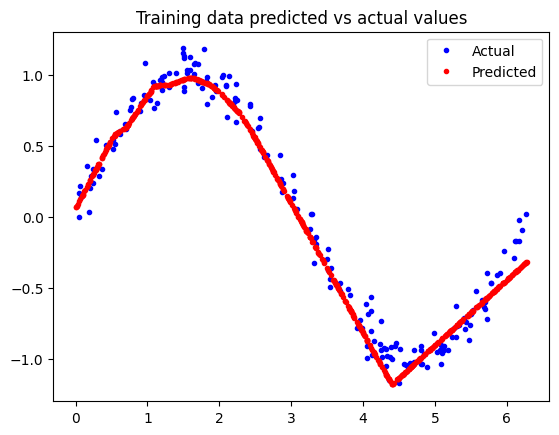

In [36]:
predictions = model_2.predict(x_train)

plt.clf()
plt.title('Training data predicted vs actual values')
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_train, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()

Test MSE: 0.014520
Test MAE: 0.093633
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


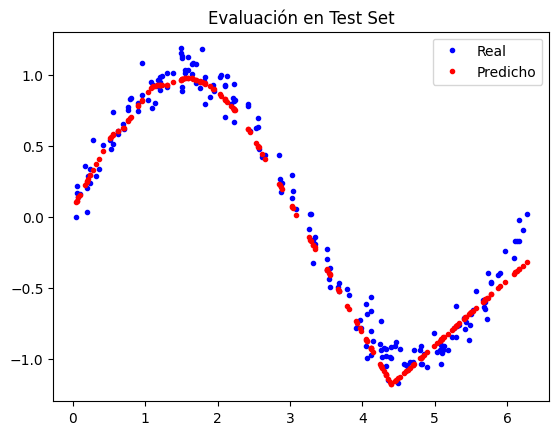

In [39]:
test_loss, test_mae = model_2.evaluate(x_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

# Y visualizar predicciones vs real en test
predictions_test = model_2.predict(x_test)
plt.plot(x_test, y_test, 'b.', label='Real')
plt.plot(x_test, predictions_test, 'r.', label='Predicho')
plt.title('Evaluación en Test Set')
plt.legend()
plt.show()

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quant_model = converter.convert()

with open ('model_quant.tflite', 'wb') as f:
  f.write(tflite_quant_model)

Saved artifact at '/tmp/tmpmvn5azcc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133704310825488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133704310824720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133704310819536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133704310818576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133704310825296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133704310825104: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [38]:
!xxd -i model_quant.tflite > sine.h